This notebook loads and compares evaluation results across all models and languages. It reads the JSON result files saved by the individual evaluation pipelines and combines them into a single pandas dataframe for easy comparison. For each model and language combination, it extracts the mean and standard deviation of precision, recall, and NDCG at all k values. The resulting dataframe provides a unified overview of all experimental results, making it straightforward to compare model performance across languages and identify patterns. This notebook serves as the central place for result analysis and can be used to generate comparison tables for the thesis.

In [2]:
import json
import pandas as pd
import numpy as np
import os

def load_results(filepath):
    with open(filepath, 'r') as f:
        return json.load(f)

# Load all result files
files = {
    'E5 English': 'results_e5_small_english.json',
    'E5 French': 'results_e5_french_enlabels.json',
    'E5 French (native labels)': 'results_e5_french_nativelabels.json',
    'E5 Dutch': 'results_e5_dutch_enlabels.json',
    'E5 Dutch (native labels)': 'results_e5_dutch_nativelabels.json',
    'E5 German': 'results_e5_german_enlabels.json',
    'E5 German (native labels)': 'results_e5_german_nativelabels.json', 

    'E5 English (reranked)': 'results_e5_reranked_en_en_labels.json',
    'E5 French (reranked)': 'results_e5_reranked_fr_en_labels.json',
    'E5 French native (reranked)': 'results_e5_reranked_fr_native_labels.json',
    'E5 Dutch (reranked)': 'results_e5_reranked_nl_en_labels.json',
    'E5 Dutch native (reranked)': 'results_e5_reranked_nl_native_labels.json',
    'E5 German (reranked)': 'results_e5_reranked_de_en_labels.json',
    'E5 German native (reranked)': 'results_e5_reranked_de_native_labels.json',

    'LaBSE English': 'results_labse_english.json',
    'LaBSE French': 'results_labse_french_enlabels.json',
    'LaBSE French (native labels)': 'results_labse_french_nativelabels.json',
    'LaBSE Dutch': 'results_labse_dutch_enlabels.json',
    'LaBSE Dutch (native labels)': 'results_labse_dutch_nativelabels.json',
    'LaBSE German': 'results_labse_german_enlabels.json',
    'LaBSE German (native labels)': 'results_labse_german_nativelabels.json',

    'OpenAI English': 'results_openai_english.json',
    'OpenAI French': 'results_openai_french_enlabels.json',
    'OpenAI French (native labels)': 'results_openai_french_nativelabels.json',
    'OpenAI Dutch': 'results_openai_dutch_enlabels.json',
    'OpenAI Dutch (native labels)': 'results_openai_dutch_nativelabels.json',
    'OpenAI German': 'results_openai_german_enlabels.json',
    'OpenAI German (native labels)': 'results_openai_german_nativelabels.json'    
}

k_values = [5, 10, 20, 50, 100]

rows = []
for model_name, filepath in files.items():
    if not os.path.exists(filepath):
        print(f"Missing: {filepath}")
        continue
    data = load_results(filepath)
    for k in k_values:
        rows.append({
            'Model': model_name,
            'k': k,
            'Precision': data['metrics']['precision'][str(k)]['mean'],
            'Recall': data['metrics']['recall'][str(k)]['mean'],
            'NDCG': data['metrics']['ndcg'][str(k)]['mean'],
            'Precision_std': data['metrics']['precision'][str(k)]['std'],
            'Recall_std': data['metrics']['recall'][str(k)]['std'],
            'NDCG_std': data['metrics']['ndcg'][str(k)]['std'],
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

                        Model   k  Precision   Recall     NDCG  Precision_std  Recall_std  NDCG_std
                   E5 English   5   0.085800 0.073409 0.095819       0.126263    0.120769  0.153945
                   E5 English  10   0.068720 0.120321 0.108793       0.077882    0.151027  0.145383
                   E5 English  20   0.053710 0.185980 0.137492       0.047421    0.178351  0.148413
                   E5 English  50   0.035244 0.300248 0.178165       0.023066    0.208393  0.148692
                   E5 English 100   0.024260 0.408209 0.209835       0.013020    0.217514  0.144981
                    E5 French   5   0.049560 0.045032 0.057713       0.097241    0.094573  0.120798
                    E5 French  10   0.046040 0.080313 0.070990       0.063658    0.117634  0.113446
                    E5 French  20   0.037060 0.123831 0.090979       0.040553    0.141754  0.117930
                    E5 French  50   0.024996 0.204539 0.119942       0.020982    0.173996  0.120891


                        Model   k  Precision   Recall     NDCG  Precision_std  Recall_std  NDCG_std
                   E5 English   5   0.085800 0.073409 0.095819       0.126263    0.120769  0.153945
                   E5 English  10   0.068720 0.120321 0.108793       0.077882    0.151027  0.145383
                   E5 English  20   0.053710 0.185980 0.137492       0.047421    0.178351  0.148413
                   E5 English  50   0.035244 0.300248 0.178165       0.023066    0.208393  0.148692
                   E5 English 100   0.024260 0.408209 0.209835       0.013020    0.217514  0.144981
                    E5 French   5   0.049560 0.045032 0.057713       0.097241    0.094573  0.120798
                    E5 French  10   0.046040 0.080313 0.070990       0.063658    0.117634  0.113446
                    E5 French  20   0.037060 0.123831 0.090979       0.040553    0.141754  0.117930
                    E5 French  50   0.024996 0.204539 0.119942       0.020982    0.173996  0.120891


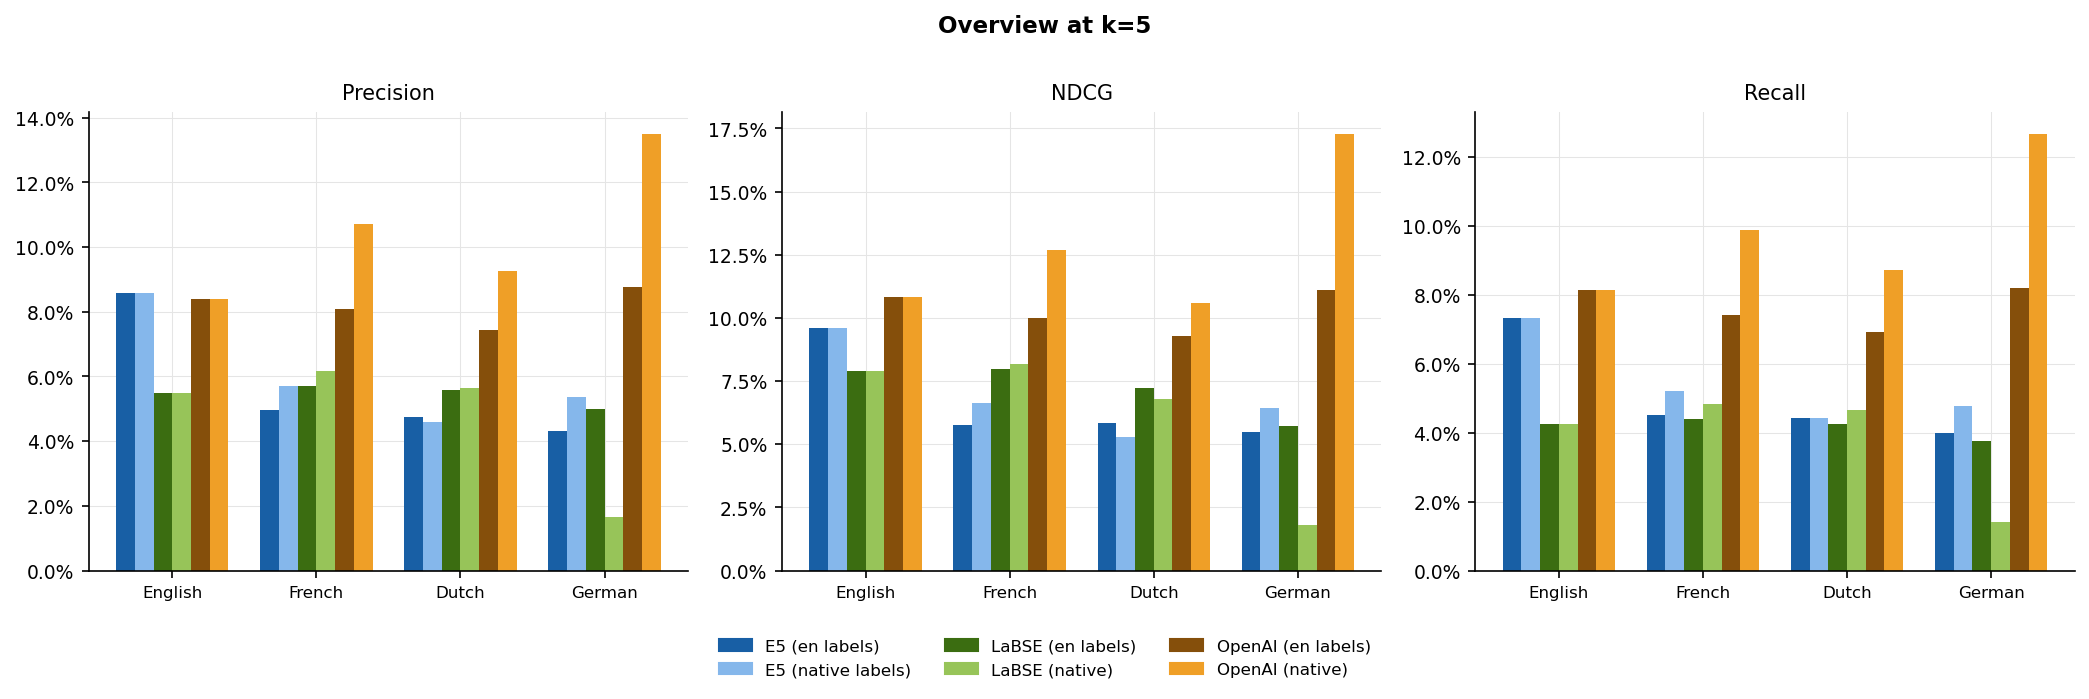

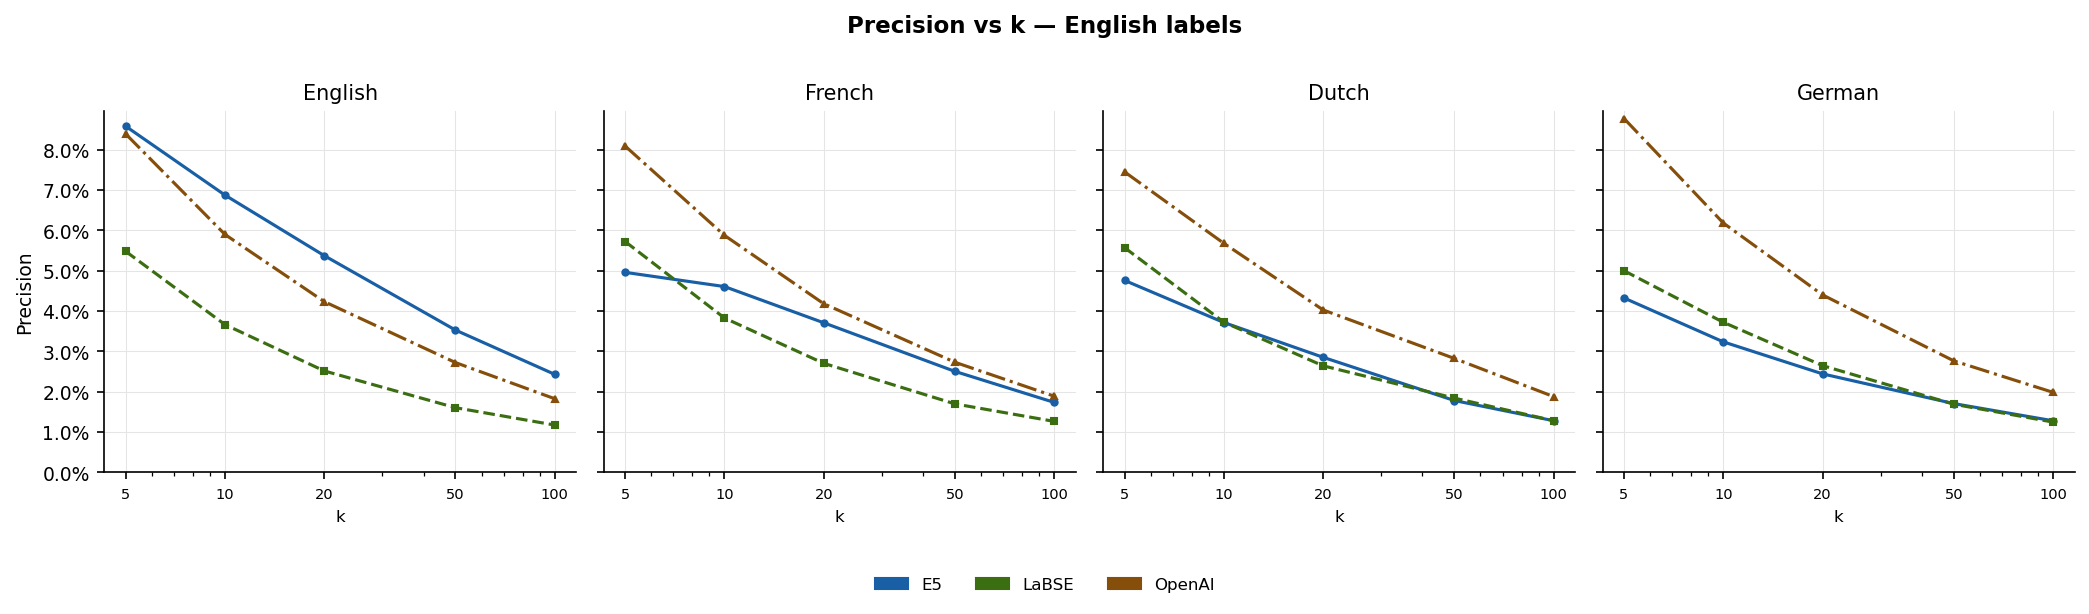

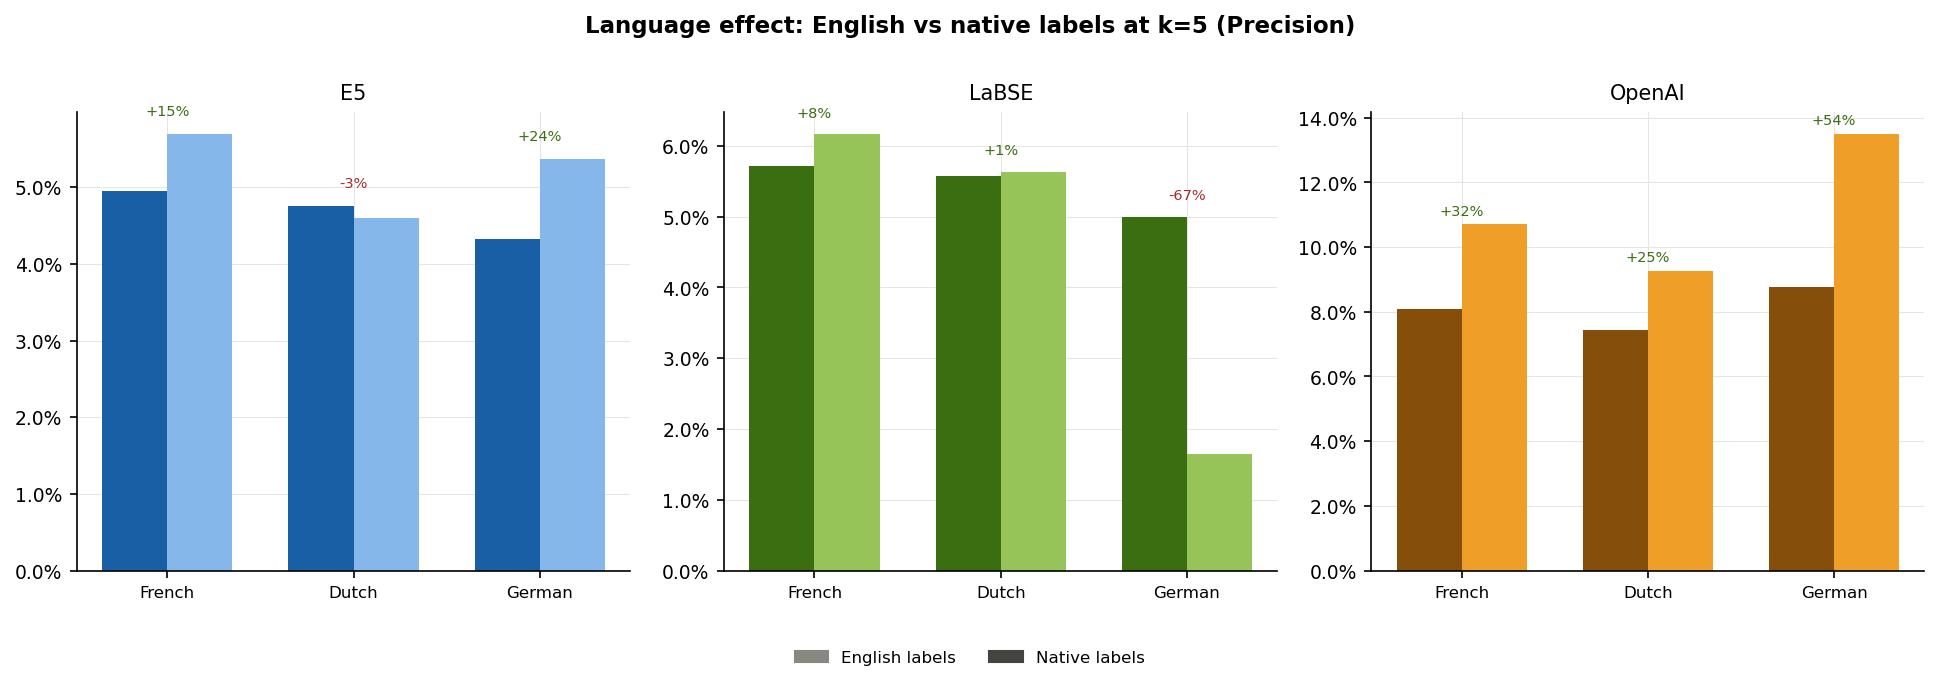

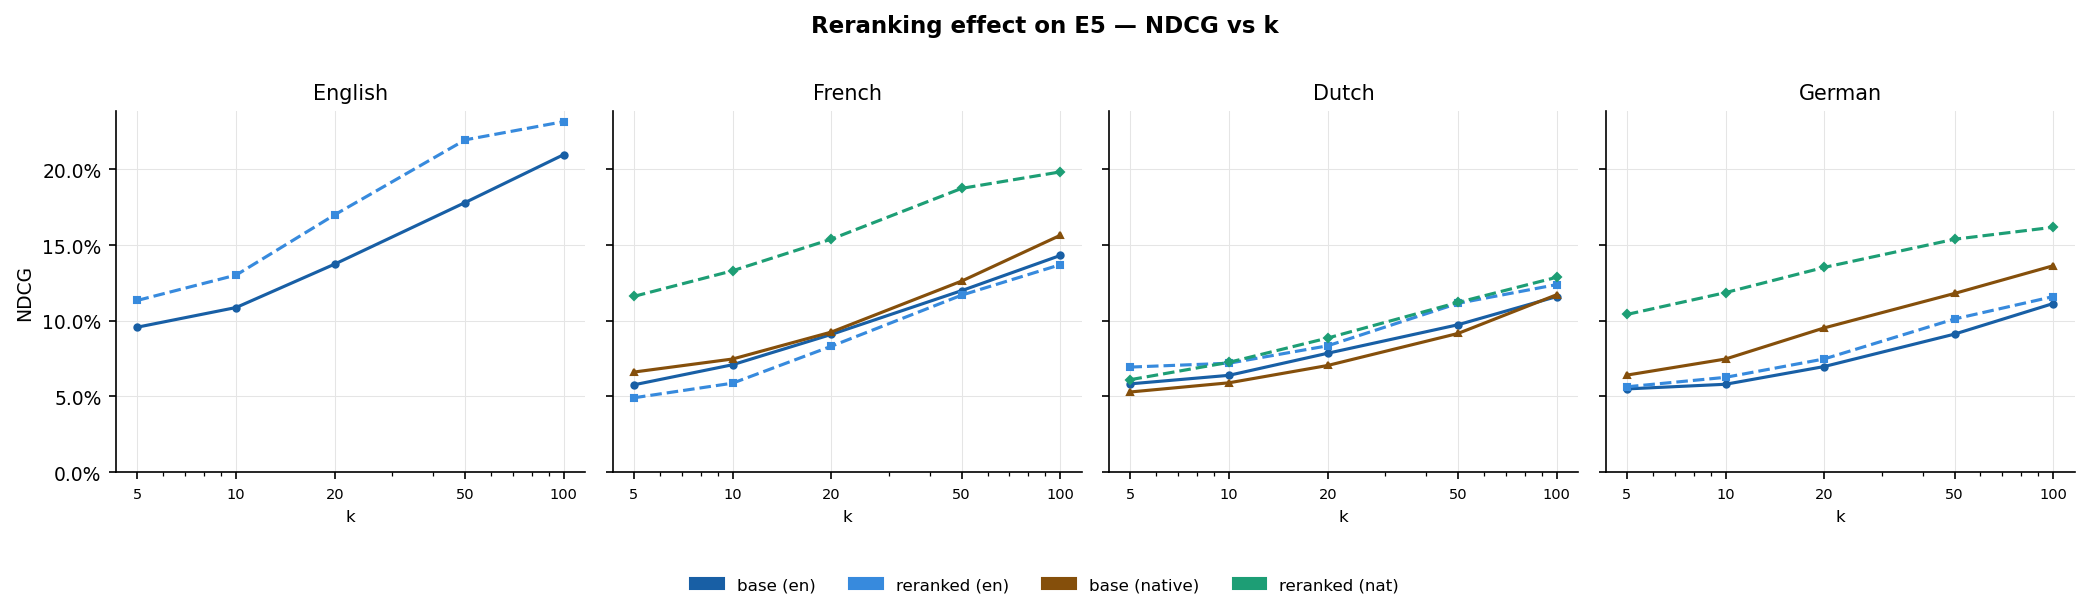

In [4]:
# ── CELL 1: load data, print table, and generate figures ─────────────────────

import json
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def load_results(filepath):
    with open(filepath, 'r') as f:
        return json.load(f)

files = {
    'E5 English':                   'results_e5_small_english.json',
    'E5 French':                    'results_e5_french_enlabels.json',
    'E5 French (native labels)':    'results_e5_french_nativelabels.json',
    'E5 Dutch':                     'results_e5_dutch_enlabels.json',
    'E5 Dutch (native labels)':     'results_e5_dutch_nativelabels.json',
    'E5 German':                    'results_e5_german_enlabels.json',
    'E5 German (native labels)':    'results_e5_german_nativelabels.json',
    'E5 English (reranked)':        'results_e5_reranked_en_en_labels.json',
    'E5 French (reranked)':         'results_e5_reranked_fr_en_labels.json',
    'E5 French native (reranked)':  'results_e5_reranked_fr_native_labels.json',
    'E5 Dutch (reranked)':          'results_e5_reranked_nl_en_labels.json',
    'E5 Dutch native (reranked)':   'results_e5_reranked_nl_native_labels.json',
    'E5 German (reranked)':         'results_e5_reranked_de_en_labels.json',
    'E5 German native (reranked)':  'results_e5_reranked_de_native_labels.json',
    'LaBSE English':                'results_labse_english.json',
    'LaBSE French':                 'results_labse_french_enlabels.json',
    'LaBSE French (native labels)': 'results_labse_french_nativelabels.json',
    'LaBSE Dutch':                  'results_labse_dutch_enlabels.json',
    'LaBSE Dutch (native labels)':  'results_labse_dutch_nativelabels.json',
    'LaBSE German':                 'results_labse_german_enlabels.json',
    'LaBSE German (native labels)': 'results_labse_german_nativelabels.json',
    'OpenAI English':               'results_openai_english.json',
    'OpenAI French':                'results_openai_french_enlabels.json',
    'OpenAI French (native labels)':'results_openai_french_nativelabels.json',
    'OpenAI Dutch':                 'results_openai_dutch_enlabels.json',
    'OpenAI Dutch (native labels)': 'results_openai_dutch_nativelabels.json',
    'OpenAI German':                'results_openai_german_enlabels.json',
    'OpenAI German (native labels)':'results_openai_german_nativelabels.json',
}

k_values = [5, 10, 20, 50, 100]
rows = []

for model_name, filepath in files.items():
    if not os.path.exists(filepath):
        print(f"Missing: {filepath}")
        continue
    data = load_results(filepath)
    for k in k_values:
        rows.append({
            'Model':         model_name,
            'k':             k,
            'Precision':     data['metrics']['precision'][str(k)]['mean'],
            'Recall':        data['metrics']['recall'][str(k)]['mean'],
            'NDCG':          data['metrics']['ndcg'][str(k)]['mean'],
            'Precision_std': data['metrics']['precision'][str(k)]['std'],
            'Recall_std':    data['metrics']['recall'][str(k)]['std'],
            'NDCG_std':      data['metrics']['ndcg'][str(k)]['std'],
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

# ── shared config ─────────────────────────────────────────────────────────────

LANGS  = ['English', 'French', 'Dutch', 'German']
NON_EN = ['French', 'Dutch', 'German']

COLORS = {
    'E5':      '#185FA5',
    'E5n':     '#85B7EB',
    'LaBSE':   '#3B6D11',
    'LaBSEn':  '#97C459',
    'OpenAI':  '#854F0B',
    'OpenAIn': '#EF9F27',
    'E5rr':    '#378ADD',
    'E5rrn':   '#1D9E75',
}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         9,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#e5e5e5',
    'grid.linewidth':    0.5,
    'axes.axisbelow':    True,
    'figure.dpi':        150,
})

fmt = plt.FuncFormatter(lambda x, _: f'{x*100:.1f}%')

def get(model, k, metric='Precision'):
    row = df[(df['Model'] == model) & (df['k'] == k)]
    return float(row[metric].values[0]) if len(row) else np.nan

def patch(label, color):
    return mpatches.Patch(color=color, label=label)

# ── figure 1: overview @ k=5 ─────────────────────────────────────────────────

groups = [
    ('E5 (en labels)',     ['E5 English', 'E5 French',                    'E5 Dutch',                  'E5 German'],                  COLORS['E5']),
    ('E5 (native labels)', ['E5 English', 'E5 French (native labels)',     'E5 Dutch (native labels)',   'E5 German (native labels)'],   COLORS['E5n']),
    ('LaBSE (en labels)',  ['LaBSE English', 'LaBSE French',               'LaBSE Dutch',               'LaBSE German'],               COLORS['LaBSE']),
    ('LaBSE (native)',     ['LaBSE English', 'LaBSE French (native labels)','LaBSE Dutch (native labels)','LaBSE German (native labels)'],COLORS['LaBSEn']),
    ('OpenAI (en labels)', ['OpenAI English', 'OpenAI French',              'OpenAI Dutch',              'OpenAI German'],              COLORS['OpenAI']),
    ('OpenAI (native)',    ['OpenAI English', 'OpenAI French (native labels)','OpenAI Dutch (native labels)','OpenAI German (native labels)'],COLORS['OpenAIn']),
]

fig1, axes = plt.subplots(1, 3, figsize=(14, 4))
fig1.suptitle('Overview at k=5', fontsize=11, fontweight='bold', y=1.01)

x = np.arange(len(LANGS))
n, w = len(groups), 0.13
offsets = np.linspace(-(n - 1) / 2 * w, (n - 1) / 2 * w, n)

for ax, metric in zip(axes, ['Precision', 'NDCG', 'Recall']):
    for (label, models, color), offset in zip(groups, offsets):
        ax.bar(x + offset, [get(m, 5, metric) for m in models], width=w, color=color)
    ax.set_title(metric, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(LANGS, fontsize=8)
    ax.yaxis.set_major_formatter(fmt)
    ax.set_ylim(bottom=0)

fig1.legend(handles=[patch(g[0], g[2]) for g in groups],
            loc='lower center', ncol=3, fontsize=8,
            bbox_to_anchor=(0.5, -0.12), frameon=False)
plt.tight_layout()
plt.show()

# ── figure 2: precision curves by language (en labels) ───────────────────────

model_lines = [
    ('E5',     COLORS['E5'],     '-',  'o'),
    ('LaBSE',  COLORS['LaBSE'],  '--', 's'),
    ('OpenAI', COLORS['OpenAI'], '-.', '^'),
]

fig2, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)
fig2.suptitle('Precision vs k — English labels', fontsize=11, fontweight='bold', y=1.01)

for ax, lang in zip(axes, LANGS):
    for base, color, ls, marker in model_lines:
        ax.plot(k_values, [get(f'{base} {lang}', k, 'Precision') for k in k_values],
                color=color, linestyle=ls, linewidth=1.5, marker=marker, markersize=3)
    ax.set_title(lang, fontsize=10)
    ax.set_xlabel('k', fontsize=8)
    ax.set_xscale('log')
    ax.set_xticks(k_values)
    ax.set_xticklabels(k_values, fontsize=7)
    ax.yaxis.set_major_formatter(fmt)
    ax.set_ylim(bottom=0)

axes[0].set_ylabel('Precision', fontsize=9)
fig2.legend(handles=[patch(b, c) for b, c, _, __ in model_lines],
            loc='lower center', ncol=3, fontsize=8,
            bbox_to_anchor=(0.5, -0.12), frameon=False)
plt.tight_layout()
plt.show()

# ── figure 3: language effect — en vs native labels at k=5 ───────────────────

native_map = {
    'E5':     {'French': 'E5 French (native labels)',     'Dutch': 'E5 Dutch (native labels)',     'German': 'E5 German (native labels)'},
    'LaBSE':  {'French': 'LaBSE French (native labels)',  'Dutch': 'LaBSE Dutch (native labels)',  'German': 'LaBSE German (native labels)'},
    'OpenAI': {'French': 'OpenAI French (native labels)', 'Dutch': 'OpenAI Dutch (native labels)', 'German': 'OpenAI German (native labels)'},
}

fig3, axes = plt.subplots(1, 3, figsize=(13, 4))
fig3.suptitle('Language effect: English vs native labels at k=5 (Precision)',
              fontsize=11, fontweight='bold', y=1.01)

x, w = np.arange(len(NON_EN)), 0.35

for ax, base in zip(axes, ['E5', 'LaBSE', 'OpenAI']):
    en_vals     = [get(f'{base} {l}', 5, 'Precision') for l in NON_EN]
    native_vals = [get(native_map[base][l], 5, 'Precision') for l in NON_EN]
    ax.bar(x - w / 2, en_vals,     width=w, color=COLORS[base],       label='English labels')
    ax.bar(x + w / 2, native_vals, width=w, color=COLORS[base + 'n'], label='Native labels')
    ax.set_title(base, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(NON_EN, fontsize=8)
    ax.yaxis.set_major_formatter(fmt)
    ax.set_ylim(bottom=0)
    for i, (ev, nv) in enumerate(zip(en_vals, native_vals)):
        if not (np.isnan(ev) or np.isnan(nv)):
            delta = (nv - ev) / ev * 100
            ax.text(i, max(ev, nv) + 0.002, f'{delta:+.0f}%',
                    ha='center', va='bottom', fontsize=7,
                    color='#3B6D11' if delta >= 0 else '#A32D2D')

fig3.legend(handles=[patch('English labels', '#888780'), patch('Native labels', '#444441')],
            loc='lower center', ncol=2, fontsize=8,
            bbox_to_anchor=(0.5, -0.1), frameon=False)
plt.tight_layout()
plt.show()

# ── figure 4: reranking effect for E5 (NDCG vs k) ────────────────────────────

rerank_configs = {
    'English': ('E5 English', 'E5 English (reranked)',      None,                        None),
    'French':  ('E5 French',  'E5 French (reranked)',       'E5 French (native labels)', 'E5 French native (reranked)'),
    'Dutch':   ('E5 Dutch',   'E5 Dutch (reranked)',        'E5 Dutch (native labels)',  'E5 Dutch native (reranked)'),
    'German':  ('E5 German',  'E5 German (reranked)',       'E5 German (native labels)', 'E5 German native (reranked)'),
}

rr_lines = [
    ('base (en)',      COLORS['E5'],     '-',  'o'),
    ('reranked (en)',  COLORS['E5rr'],   '--', 's'),
    ('base (native)',  COLORS['OpenAI'], '-',  '^'),
    ('reranked (nat)', COLORS['E5rrn'],  '--', 'D'),
]

fig4, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)
fig4.suptitle('Reranking effect on E5 — NDCG vs k', fontsize=11, fontweight='bold', y=1.01)

for ax, lang in zip(axes, LANGS):
    for (label, color, ls, marker), model in zip(rr_lines, rerank_configs[lang]):
        if model is None:
            continue
        ax.plot(k_values, [get(model, k, 'NDCG') for k in k_values],
                color=color, linestyle=ls, linewidth=1.5, marker=marker, markersize=3)
    ax.set_title(lang, fontsize=10)
    ax.set_xlabel('k', fontsize=8)
    ax.set_xscale('log')
    ax.set_xticks(k_values)
    ax.set_xticklabels(k_values, fontsize=7)
    ax.yaxis.set_major_formatter(fmt)
    ax.set_ylim(bottom=0)

axes[0].set_ylabel('NDCG', fontsize=9)
fig4.legend(handles=[patch(l, c) for l, c, _, __ in rr_lines],
            loc='lower center', ncol=4, fontsize=8,
            bbox_to_anchor=(0.5, -0.12), frameon=False)
plt.tight_layout()
plt.show()


In [ ]:
# import os
# save_dir = '.'  # change to your preferred output folder
# os.makedirs(save_dir, exist_ok=True)
#
# fig1.savefig(os.path.join(save_dir, 'fig1_overview_k5.png'),          bbox_inches='tight', dpi=300)
# fig2.savefig(os.path.join(save_dir, 'fig2_precision_curves.png'),     bbox_inches='tight', dpi=300)
# fig3.savefig(os.path.join(save_dir, 'fig3_language_effect.png'),      bbox_inches='tight', dpi=300)
# fig4.savefig(os.path.join(save_dir, 'fig4_reranking_effect.png'),     bbox_inches='tight', dpi=300)
# print(f"Figures saved to {os.path.abspath(save_dir)}")
